실습 3. 이상 의심 구간 표시하기
- 이동표준편차로 변동성을 추적하고 의심 구간 색칠

목표
- 이동표준편차로 변동성을 추적하고 의심 구간을 색으로 표시

단계
- 창 크기 20으로 이동표준편차를 구하기
- 위칸에 원본, 아래칸에 이동표준편차를 그리기
- 변동성이 커지는 후반 구간을 색 영역으로 표시

예상 결과
- 후반 구간에서 이동표준편차가 치솟고 색칠된 의심 구간과 겹침

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/21_cmapss_fd001_sample.csv')
print(df.shape)

sensors = ['s_2', 's_3', 's_4', 's_7', 's_11']

(1031, 10)


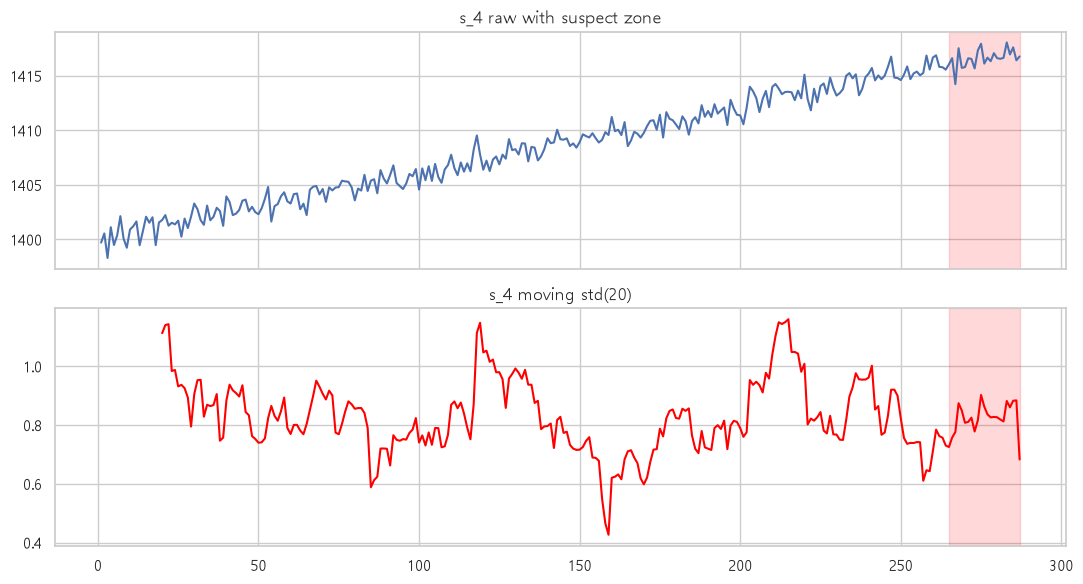

In [4]:
# [axvspan을 이용한 시계열 이상 의심 구간 시각적 음영 하이라이트]
# 1. std20: 20-사이클 이동표준편차 변동성 시리즈를 정의합니다.
# 2. ax1.axvspan(265, 287): x축의 265 사이클부터 287 사이클까지의 배경에 옅은 빨간색 영역(Span)을 생성합니다.
# 3. sharex=True: 위아래 두 서브플롯의 가로축을 강제 바인딩하여 마우스 줌이나 플로팅 범위를 동기화합니다.
# * 엔진이 수명 임계치 근처에 다다라 급격한 진동(이동표준편차 피크)을 나타내는 고장 임박 구간을
#   관람자에게 직관적이고 경고 효과를 주기 위해 차트에 음영으로 배경을 도포해 줍니다.
# * `alpha=0.15`와 같이 투명도를 낮추지 않고 불투명하게(1.0) 그리면
#   배경이 원본 그래프 선을 완전히 덮어써 보이지 않게 되는 실수가 흔히 발생합니다.
eng_02 = df[df['unit_nr'] == 2].reset_index(drop=True)

std20 = eng_02['s_4'].rolling(20).std()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(eng_02['time_cycles'], eng_02['s_4'])
ax1.axvspan(265, 287, color='red', alpha=0.15)
ax1.set_title('s_4 raw with suspect zone')

ax2.plot(eng_02['time_cycles'], std20, color='red')
ax2.axvspan(265, 287, color='red', alpha=0.15)
ax2.set_title('s_4 moving std(20)')

plt.tight_layout()
plt.show()